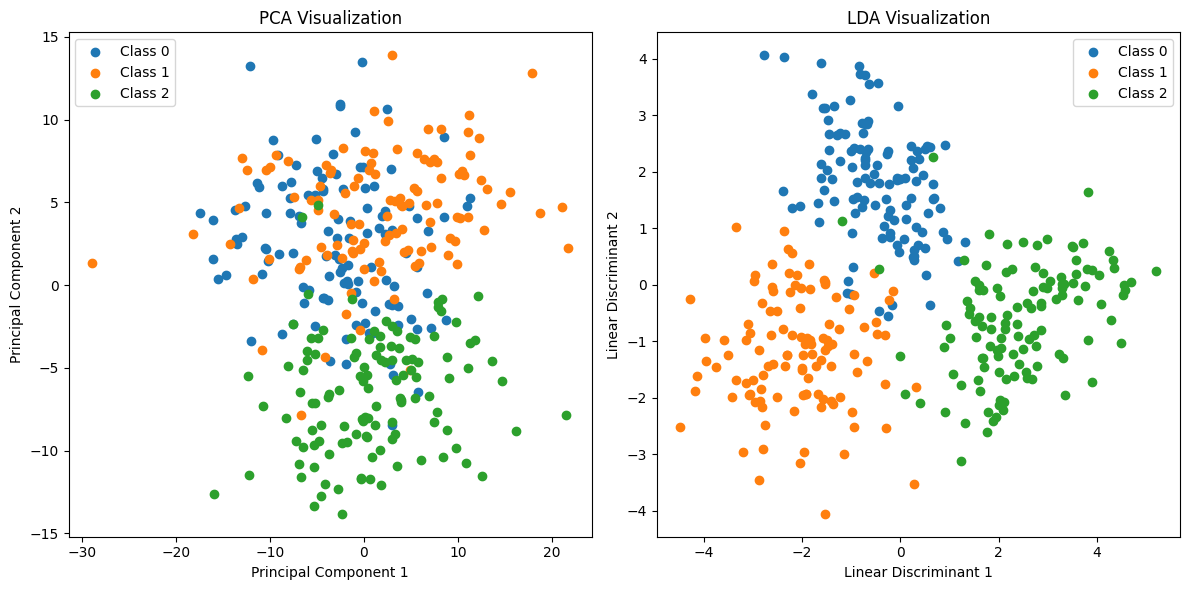

Accuracy on Original Data: 0.94
Accuracy on PCA-Reduced Data: 0.71
Accuracy on LDA-Reduced Data: 0.90


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Step 1: Generate a high-dimensional synthetic dataset
X, y = make_classification(n_samples=500, n_features=50, n_informative=10, n_redundant=10,
                           n_classes=3, n_clusters_per_class=1, random_state=42)

# Step 2: Split dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Apply PCA
pca = PCA(n_components=2) # Reduce to 2 components
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Step 4: Apply LDA
lda = LDA(n_components=2) # Reduce to 2 components
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)

# Step 5: Visualize PCA and LDA results
plt.figure(figsize=(12, 6))

# PCA visualization
plt.subplot(1, 2, 1)
for class_value in np.unique(y_train):
    plt.scatter(X_train_pca[y_train == class_value, 0], X_train_pca[y_train == class_value, 1], label=f'Class {class_value}')
plt.title("PCA Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()

# LDA visualization
plt.subplot(1, 2, 2)
for class_value in np.unique(y_train):
    plt.scatter(X_train_lda[y_train == class_value, 0], X_train_lda[y_train == class_value, 1], label=f'Class {class_value}')
plt.title("LDA Visualization")
plt.xlabel("Linear Discriminant 1")
plt.ylabel("Linear Discriminant 2")
plt.legend()

plt.tight_layout()
plt.show()

# Step 6: Compare classification performance
# Train classifier on original data
clf_original = RandomForestClassifier(random_state=42)
clf_original.fit(X_train, y_train)
y_pred_original = clf_original.predict(X_test)
original_accuracy = accuracy_score(y_test, y_pred_original)

# Train classifier on PCA-transformed data
clf_pca = RandomForestClassifier(random_state=42)
clf_pca.fit(X_train_pca, y_train)
y_pred_pca = clf_pca.predict(X_test_pca)
pca_accuracy = accuracy_score(y_test, y_pred_pca)

# Train classifier on LDA-transformed data
clf_lda = RandomForestClassifier(random_state=42)
clf_lda.fit(X_train_lda, y_train)
y_pred_lda = clf_lda.predict(X_test_lda)
lda_accuracy = accuracy_score(y_test, y_pred_lda)

# Print accuracy comparison
print(f'Accuracy on Original Data: {original_accuracy:.2f}')
print(f'Accuracy on PCA-Reduced Data: {pca_accuracy:.2f}')
print(f'Accuracy on LDA-Reduced Data: {lda_accuracy:.2f}')